# Podaci: učitavanje, analiza, čišćenje i podela

Od originalnog CSV-a dolazimo do očišćenih poruka i odvojenog trening i test skupa. Reproduktivna pravila su u `src/`; ovde prikazujemo podatke, grafikone i provere.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.data_loading import load_raw_sms
from src.preprocessing import prepare_sms

raw = load_raw_sms()
raw.shape

(5572, 5)

## 1. Originalni podaci

`v1` je oznaka klase, `v2` početak poruke. Dodatne kolone ponekad sadrže nastavak.

In [2]:
raw[["v1", "v2"]].head(3)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


In [3]:
print("Broj poruka po klasi:")
print(raw["v1"].value_counts())
print("Redovi sa sadržajem u dodatnim kolonama:", raw.iloc[:, 2:].notna().any(axis=1).sum())

Broj poruka po klasi:
v1
ham     4825
spam     747
Name: count, dtype: int64
Redovi sa sadržajem u dodatnim kolonama: 50


## 2. Struktura i nedostajuće vrednosti

`isna()` pokazuje prazne ćelije. Tri dodatne kolone su skoro prazne, ali 50 redova ima u njima nastavak poruke. Zato ih ne odbacujemo pre spajanja teksta.

In [4]:
print('Prazne ćelije po koloni:')
print(raw.isna().sum().to_string())
extra_columns = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
continued = raw[extra_columns].notna().any(axis=1)
print('Redovi sa nastavkom:', continued.sum())
raw.loc[continued, ['v1', 'v2', *extra_columns]].head(3)

Prazne ćelije po koloni:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
Redovi sa nastavkom: 50


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,NaN,NaN


## 3. Jedno pravilo čišćenja

Delove poruke spajamo zarezom redom kojim stoje u CSV-u i uklanjamo samo praznine na početku i kraju. Ne pretvaramo tekst u mala slova i ne brišemo interpunkciju, jer znakovi i velika slova mogu biti korisni za prepoznavanje spama. Zatim uklanjamo potpuno identične poruke. Ako bi ista poruka imala obe oznake, obrada bi se zaustavila greškom umesto da proizvoljno izabere jednu.

In [5]:
clean = prepare_sms(raw)
print('Originalnih redova:', len(raw))
print('Jedinstvenih poruka:', len(clean))
print('Uklonjenih tačnih duplikata:', len(raw) - len(clean))
print('Preostali duplikati teksta:', clean.duplicated('text').sum())
print('Prazni tekstovi:', clean['text'].eq('').sum())
clean.head(3)

Originalnih redova: 5572
Jedinstvenih poruka: 5158
Uklonjenih tačnih duplikata: 414
Preostali duplikati teksta: 0
Prazni tekstovi: 0


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


### Koliko je duplikata uklonjeno iz svake klase?

Pored ukupnog broja uklonjenih redova gledamo i njihov udeo unutar svake klase. Tako možemo da proverimo da li je čišćenje promenilo sastav skupa na različit način za `ham` i `spam`. Ovo su ponovljeni, potpuno isti tekstovi, a ne različite poruke sa sličnim značenjem.

      pre čišćenja  posle čišćenja  uklonjeno  uklonjeno_%_klase
ham           4825            4516        309               6.40
spam           747             642        105              14.06


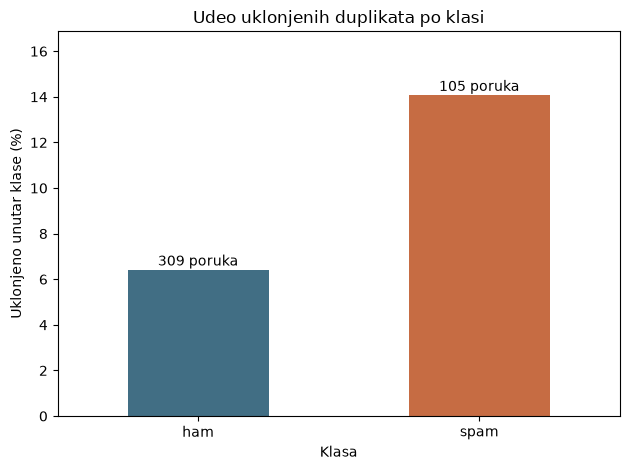

In [6]:
before = raw['v1'].value_counts().reindex(['ham', 'spam'])
after = clean['label'].value_counts().reindex(['ham', 'spam'])
removed = before - after
duplicate_summary = pd.DataFrame({
    'pre čišćenja': before,
    'posle čišćenja': after,
    'uklonjeno': removed,
    'uklonjeno_%_klase': (removed / before * 100).round(2),
})
print(duplicate_summary.to_string())
ax = duplicate_summary['uklonjeno_%_klase'].plot.bar(color=['#416e84', '#c66c43'], rot=0)
ax.set(title='Udeo uklonjenih duplikata po klasi', xlabel='Klasa', ylabel='Uklonjeno unutar klase (%)')
for index, count in enumerate(removed):
    ax.text(index, duplicate_summary['uklonjeno_%_klase'].iloc[index] + 0.2, f'{count} poruka', ha='center')
ax.set_ylim(0, duplicate_summary['uklonjeno_%_klase'].max() * 1.2)
plt.tight_layout()
plt.show()

## 4. Raspodela klasa

`ham` je regularna, a `spam` neželjena poruka. Pored apsolutnog broja gledamo i udeo, jer neuravnotežen skup utiče na izbor metrika: sama tačnost može da zavara ako model pretežno predviđa većinsku klasu.

       broj  udeo_%
label              
ham    4516   87.55
spam    642   12.45


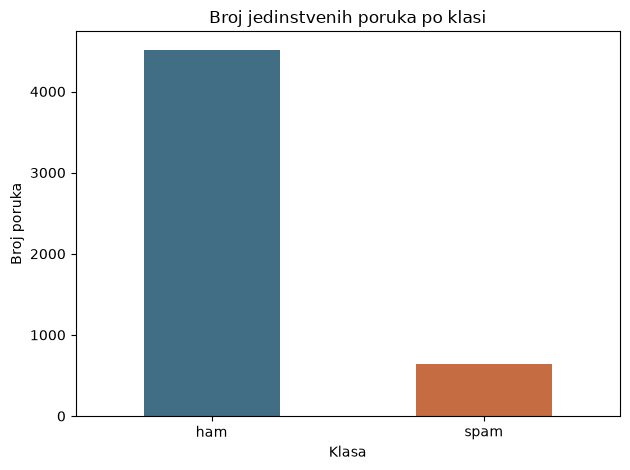

In [7]:
counts = clean['label'].value_counts().reindex(['ham', 'spam'])
print(pd.DataFrame({'broj': counts, 'udeo_%': (counts / len(clean) * 100).round(2)}).to_string())
ax = counts.plot.bar(color=['#416e84', '#c66c43'], rot=0)
ax.set(title='Broj jedinstvenih poruka po klasi', xlabel='Klasa', ylabel='Broj poruka')
plt.tight_layout()
plt.show()

## 5. Dužina poruka

Merimo broj znakova i reči posle čišćenja. Histogram prikazuje koliko su poruke dugačke. Ekstremno dugačke poruke su i dalje prisutne: zbog preglednosti grafika prikazujemo samo opseg do 99. percentila, a pun raspon navodimo brojčano.

      char_count                                                word_count                                          
           count   mean   std   min    25%    50%    75%    max      count  mean   std  min   25%   50%   75%    max
label                                                                                                               
ham       4516.0   71.0  56.7   2.0   34.0   53.0   92.0  910.0     4516.0  14.2  11.2  1.0   7.0  11.0  19.0  171.0
spam       642.0  137.9  30.1  13.0  132.0  148.5  157.0  224.0      642.0  23.7   6.0  2.0  21.2  25.0  28.0   35.0
Najduža poruka: 910 znakova; prikaz do 99. percentila: 267


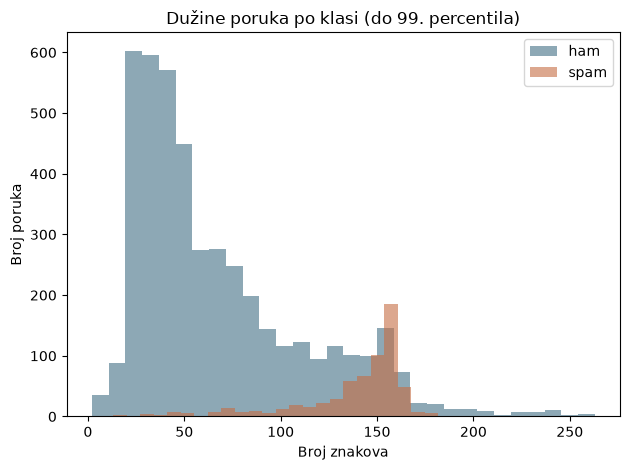

In [8]:
analysis = clean.assign(
    char_count=clean['text'].str.len(),
    word_count=clean['text'].str.split().str.len(),
    is_spam=clean['label'].eq('spam').astype(int),
)
print(analysis.groupby('label')[['char_count', 'word_count']].describe().round(1).to_string())
limit = analysis['char_count'].quantile(0.99)
print('Najduža poruka:', analysis['char_count'].max(), 'znakova; prikaz do 99. percentila:', round(limit))
for label, color in [('ham', '#416e84'), ('spam', '#c66c43')]:
    lengths = analysis.loc[analysis['label'].eq(label), 'char_count']
    plt.hist(lengths[lengths <= limit], bins=30, alpha=0.6, label=label, color=color)
plt.xlabel('Broj znakova')
plt.ylabel('Broj poruka')
plt.title('Dužine poruka po klasi (do 99. percentila)')
plt.legend()
plt.tight_layout()
plt.show()

### Poređenje raspodela bez uticaja različitog broja poruka

Prethodni histogram prikazuje broj poruka, pa je `ham` vizuelno dominantan i zato što ga ima mnogo više. Ovde svaka klasa ima sopstvenu osnovu od 100%: visina pokazuje koliki deo **te klase** ima određenu dužinu. Koristimo iste intervale za obe klase. Kao i gore, poruke iznad 99. percentila ostaju u podacima, ali nisu prikazane na osi.

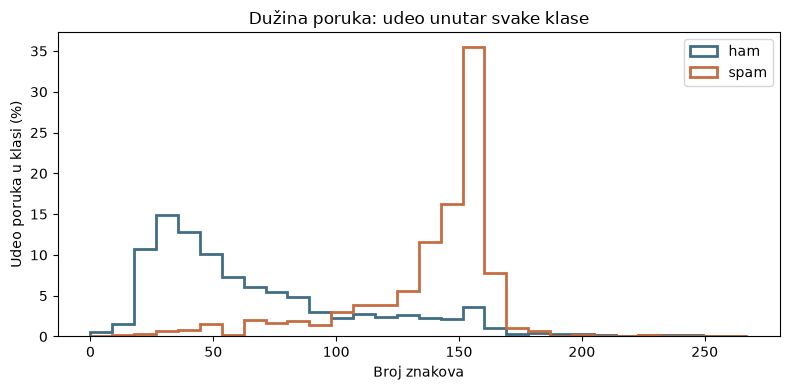

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [('ham', '#416e84'), ('spam', '#c66c43')]:
    all_lengths = analysis.loc[analysis['label'].eq(label), 'char_count']
    visible = all_lengths[all_lengths <= limit]
    ax.hist(visible, bins=30, range=(0, limit), weights=[100 / len(all_lengths)] * len(visible),
            histtype='step', linewidth=2, label=label, color=color)
ax.set(title='Dužina poruka: udeo unutar svake klase', xlabel='Broj znakova', ylabel='Udeo poruka u klasi (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Korelacije osnovnih numeričkih osobina

Pearsonova korelacija od −1 do 1 meri linearnu vezu. Ovde je koristimo samo opisno: veza dužine i oznake nije dokaz uzročnosti niti procena kvaliteta modela. `is_spam=1` označava spam.

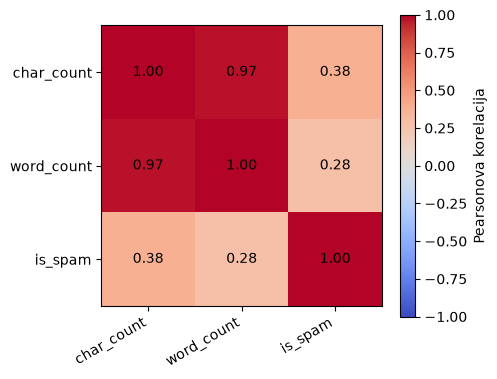

In [10]:
features = ['char_count', 'word_count', 'is_spam']
correlations = analysis[features].corr()
fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(correlations, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(features)), features, rotation=30, ha='right')
ax.set_yticks(range(len(features)), features)
for row in range(len(features)):
    for column in range(len(features)):
        ax.text(column, row, f'{correlations.iloc[row, column]:.2f}', ha='center', va='center')
fig.colorbar(image, ax=ax, label='Pearsonova korelacija')
fig.tight_layout()
plt.show()

## 7. Podela na trening i izdvojeni test

Duplikate uklanjamo pre podele. Oko 20% svake klase odlazi u izdvojeni test. Ovde rezultat ostaje u memoriji; `python -m src.split_data` čuva CSV fajlove za naredne sveske.

In [11]:
from src.split_data import RANDOM_SEED, TEST_FRACTION, split_sms

train, test = split_sms(clean)
print("Ukupno:", len(clean), "Trening:", len(train), "Test:", len(test))

Ukupno: 5158 Trening: 4127 Test: 1031


### Zašto stratifikovana podela?

Skup ima mnogo više `ham` nego `spam` poruka. Zato nasumično biramo približno 20% **iz svake klase** za test. Tako odnos klasa ostaje sličan u oba dela. `random_seed` omogućava da isti kod ponovo dobije istu podelu na istim podacima.

In [12]:
print('Udeo testa:', TEST_FRACTION, 'Nasumično seme:', RANDOM_SEED)
summary = pd.DataFrame({
    'trening_broj': train['label'].value_counts(),
    'trening_%': train['label'].value_counts(normalize=True).mul(100).round(2),
    'test_broj': test['label'].value_counts(),
    'test_%': test['label'].value_counts(normalize=True).mul(100).round(2),
}).reindex(['ham', 'spam'])
summary

Udeo testa: 0.2 Nasumično seme: 42


,trening_broj,trening_%,test_broj,test_%
label,,,,
ham,3613,87.55,903,87.58
spam,514,12.45,128,12.42


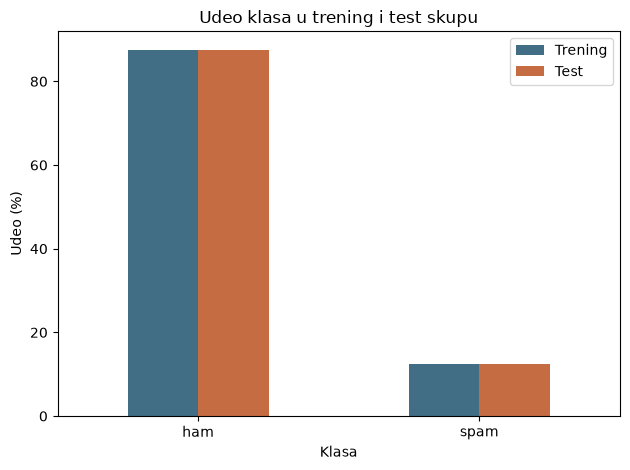

In [13]:
ax = summary[['trening_%', 'test_%']].plot.bar(rot=0, color=['#416e84', '#c66c43'])
ax.set(title='Udeo klasa u trening i test skupu', xlabel='Klasa', ylabel='Udeo (%)')
ax.legend(['Trening', 'Test'])
plt.tight_layout()
plt.show()

### Provera da nema preklapanja

Ako se isti tekst nalazi u oba dela, test ne bi bio nezavisan. Proveravamo samo broj preklapanja; **ne pregledamo tekstove test poruka** i ne koristimo test za odluke o modelu.

In [14]:
overlap = set(train['text']) & set(test['text'])
print('Isti tekst u oba skupa:', len(overlap))
print('Svi redovi sačuvani:', len(train) + len(test) == len(clean))
assert not overlap
assert len(train) + len(test) == len(clean)

Isti tekst u oba skupa: 0
Svi redovi sačuvani: True


**Dalje:** rečnik i dužinu nizova određujemo na osnovu trening skupa. U cross-validaciji pravimo nov rečnik za svaki trening fold; izdvojeni test ostaje po strani.